# 🏦 Credit Card Default Prediction — Feature Engineering

## Overview
This notebook builds on the findings from the EDA notebook to engineer new features that better capture the underlying patterns in the data. The goal is to create two datasets — a baseline dataset and a featured dataset — which will be used to compare model performance in the modeling notebook and measure the impact of feature engineering.

The preprocessed data is loaded from `data/processed/data_preprocessed.csv` — the output of `src/data_preprocessing.py`.

---

## Dataset Recap
Based on EDA findings, the key limitations of the raw features are:
- **BILL_AMT1–6** are highly intercorrelated (0.80–0.95) and weak predictors on their own — their value lies in their relationship to the credit limit
- **PAY_AMT1–6** carry consistent signal across all 6 months — better captured as an aggregate than 6 separate columns
- **LIMIT_BAL** is right-skewed — a log transform will help linear models handle it better
- **Raw numerical features show very weak linear correlation with the target** — engineered ratio features are expected to be significantly more predictive

---

## Approach — Ablation Study
Rather than just engineering features and hoping for improvement, this notebook follows an ablation study approach — building two separate datasets and comparing model performance on each:

- **Baseline dataset** (`data_baseline.csv`) — cleaned data with multicollinearity handled (BILL_AMT2–6 dropped) and LOG_LIMIT_BAL added. No engineered features.
- **Featured dataset** (`data_featured.csv`) — engineered features replacing the raw columns.

This allows us to concretely measure how much feature engineering improves model performance.

---

## Feature Engineering Plan

### Baseline Dataset
- Keep all original features except BILL_AMT2–6 (dropped due to multicollinearity — correlation of 0.80–0.95 with BILL_AMT1)
- Replace LIMIT_BAL with LOG_LIMIT_BAL (log transform — LIMIT_BAL is right skewed with no zero or negative values)
- Save → `data_baseline.csv`

### Featured Dataset

#### 1. Ratio Features
- **`BILL_LIMIT_RATIO`** — `BILL_AMT1 / LIMIT_BAL`: captures credit utilisation. A customer billing close to their limit is under more financial pressure than one with a large unused credit buffer. More predictive than raw bill amount alone.
- **`PAYMENT_RATIO`** — `PAY_AMT1 / BILL_AMT1`: captures how much of the most recent bill was actually paid. Required careful handling of edge cases — see dedicated markdown cells below.

#### 2. Aggregate Features
- **`TOTAL_PAID_6MONTHS`** — sum of all PAY_AMT columns: aggregates the consistent payment behaviour signal observed across all 6 months into a single feature, replacing 6 mildly correlated columns.

#### 3. Log Transform
- **`LOG_LIMIT_BAL`** — log transform of LIMIT_BAL applied upfront (safe since LIMIT_BAL has no zero or negative values). All other skewed features (BILL_LIMIT_RATIO, PAYMENT_RATIO, TOTAL_PAID_6MONTHS) will be handled by Yeo-Johnson transformation inside the modeling pipeline.

#### 4. Columns Dropped
- BILL_AMT1–6 — replaced by BILL_LIMIT_RATIO
- PAY_AMT1–6 — replaced by TOTAL_PAID_6MONTHS
- LIMIT_BAL — replaced by LOG_LIMIT_BAL

---

## Skew & Outlier Handling Strategy
Financial data naturally contains extreme outliers and skewed distributions — removing them would lose valuable signal. Instead:
- **Upfront (this notebook):** Log transform for LIMIT_BAL only (safe — no negative values)
- **Inside pipeline (modeling notebook):** Yeo-Johnson transformation for all other numerical features — handles negative values, zeros and extreme skew without removing any data points
- **Capping:** Applied only to PAYMENT_RATIO where mathematical artifacts (division by near-zero values) produced extreme values with no meaningful signal

---

## Objectives
1. Create a clean baseline dataset for model comparison
2. Engineer ratio and aggregate features motivated by EDA findings
3. Handle edge cases in engineered features carefully and document all decisions
4. Validate new features with visualisations confirming skew and predictive signal
5. Save both datasets to `data/processed/` for use in `modeling.ipynb`

In [146]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [147]:
# Loading dataset
df = pd.read_csv('../data/processed/data_preprocessed.csv')
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [148]:
df.shape

(29965, 24)

### Baseline Datasets

In [149]:
df_baseline = df.drop(columns=['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6'])
df_baseline.shape

(29965, 19)

In [150]:
# Log transformation of LIMIT_BAL
df_baseline['LOG_LIMIT_BAL'] = np.log(df_baseline['LIMIT_BAL'])
df_baseline = df_baseline.drop(columns=['LIMIT_BAL'])
df_baseline['LOG_LIMIT_BAL'].head()

0     9.903488
1    11.695247
2    11.407565
3    10.819778
4    10.819778
Name: LOG_LIMIT_BAL, dtype: float64

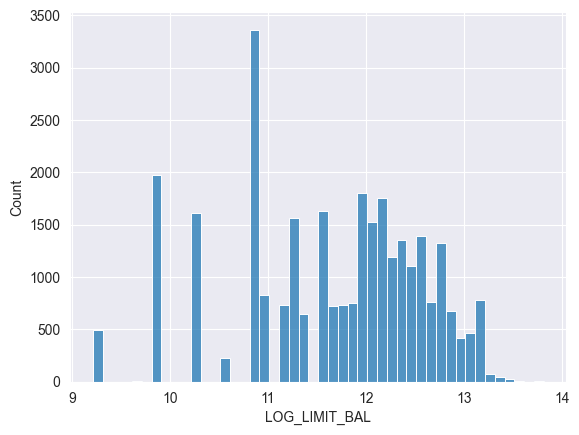

In [151]:
#Plotting histplot of LOG_LIMIT_BAL
sns.histplot(data=df_baseline, x='LOG_LIMIT_BAL')
plt.show()

### Featured Dataset

In [153]:
# Creating df_featured
df_featured = df.copy()

In [154]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [155]:
# Adding BILL_LIMIT_RATIO
df_featured['BILL_LIMIT_RATIO'] = df_featured['BILL_AMT1'] / df_featured['LIMIT_BAL']

# Adding PAYMENT_RATIO
df_featured['PAYMENT_RATIO'] = df_featured['PAY_AMT1'] / df_featured['BILL_AMT1']

# Adding TOTAL_PAID_6MONTHS
PAY_AMT_cols = [f'PAY_AMT{i}' for i in range(1, 7)]
df_featured['TOTAL_PAID_6MONTHS'] = df_featured[PAY_AMT_cols].sum(axis=1)

In [156]:
# Log transformation of LIMIT_BAL
df_featured['LOG_LIMIT_BAL'] = np.log(df_featured['LIMIT_BAL'])

In [157]:
# Dropping unnecessary columns
BILL_AMT_cols = [f'BILL_AMT{i}' for i in range (1, 7)]
df_featured = df_featured.drop(columns= ['LIMIT_BAL'] + PAY_AMT_cols + BILL_AMT_cols)
df_featured.shape

(29965, 15)

In [158]:
df_featured.head()

,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,default.payment.next.month,BILL_LIMIT_RATIO,PAYMENT_RATIO,TOTAL_PAID_6MONTHS,LOG_LIMIT_BAL
0,2,2,1,24,2,2,-1,-1,-2,-2,1,0.195650,0.000000,689.0,9.903488
1,2,2,2,26,-1,2,0,0,0,2,1,0.022350,0.000000,5000.0,11.695247
2,2,2,2,34,0,0,0,0,0,0,0,0.324878,0.051917,11018.0,11.407565
3,2,2,1,37,0,0,0,0,0,0,0,0.939800,0.042562,8388.0,10.819778
4,1,2,1,57,-1,0,-1,0,0,0,0,0.172340,0.232099,59049.0,10.819778


In [159]:
df_featured.columns

Index(['SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3',
       'PAY_4', 'PAY_5', 'PAY_6', 'default.payment.next.month',
       'BILL_LIMIT_RATIO', 'PAYMENT_RATIO', 'TOTAL_PAID_6MONTHS',
       'LOG_LIMIT_BAL'],
      dtype='object')

## Feature Engineering — PAYMENT_RATIO

In [160]:
# Check for potential division by zero issues in PAYMENT_RATIO
print(f"Zeros in BILL_AMT1: {(df['BILL_AMT1'] == 0).sum()}")
print(f"Negative values in BILL_AMT1: {(df['BILL_AMT1'] < 0).sum()}")
print(f"NaN in PAYMENT_RATIO: {df_featured['PAYMENT_RATIO'].isna().sum()}")
print(f"Inf in PAYMENT_RATIO: {np.isinf(df_featured['PAYMENT_RATIO']).sum()}")

Zeros in BILL_AMT1: 1978
Negative values in BILL_AMT1: 590
NaN in PAYMENT_RATIO: 1438
Inf in PAYMENT_RATIO: 540


In [161]:
# Explore distribution of valid PAYMENT_RATIO values
valid_ratio = df_featured['PAYMENT_RATIO'][
    ~np.isinf(df_featured['PAYMENT_RATIO']) &
    ~df_featured['PAYMENT_RATIO'].isna()
]

print("Distribution of valid PAYMENT_RATIO values:")
print(valid_ratio.describe())
print("\nKey percentiles:")
print(valid_ratio.quantile([0.25, 0.5, 0.75, 0.90, 0.95, 0.99]))
print(f"\nMax value: {valid_ratio.max()}")

Distribution of valid PAYMENT_RATIO values:
count    27987.000000
mean        -2.387482
std        239.285152
min     -35436.000000
25%          0.036641
50%          0.058703
75%          0.257791
max      11453.666667
Name: PAYMENT_RATIO, dtype: float64

Key percentiles:
0.25     0.036641
0.50     0.058703
0.75     0.257791
0.90     1.169389
0.95     2.753480
0.99    16.887505
Name: PAYMENT_RATIO, dtype: float64

Max value: 11453.666666666666


In [162]:
# Fix PAYMENT_RATIO edge cases based on distribution analysis
# Case 1: BILL_AMT1 = 0, PAY_AMT1 = 0 → NaN → set to 0 (neutral behaviour)
df_featured['PAYMENT_RATIO'] = df_featured['PAYMENT_RATIO'].fillna(0)

# Case 2 & 4: inf and extreme outliers → cap at 99th percentile
# inf occurs when BILL_AMT1 = 0 but PAY_AMT1 > 0 (payment with no bill — strong positive signal)
# extreme outliers above 99th percentile are noise, not meaningful signal
cap_value = valid_ratio.quantile(0.99)
df_featured['PAYMENT_RATIO'] = df_featured['PAYMENT_RATIO'].replace([np.inf, -np.inf], cap_value)
df_featured['PAYMENT_RATIO'] = df_featured['PAYMENT_RATIO'].clip(upper=cap_value)

# Case 3: negative values (BILL_AMT1 < 0) kept as-is
# negative bill = customer in credit (overpaid previously) — meaningful signal preserved

print(f"Cap value used (99th percentile): {cap_value:.4f}")

Cap value used (99th percentile): 16.8875


In [163]:
# Verify all edge cases are resolved
print(f"NaN remaining: {df_featured['PAYMENT_RATIO'].isna().sum()}")
print(f"Inf remaining: {np.isinf(df_featured['PAYMENT_RATIO']).sum()}")
print(f"\nUpdated distribution:")
print(df_featured['PAYMENT_RATIO'].describe())

NaN remaining: 0
Inf remaining: 0

Updated distribution:
count    29965.000000
mean        -2.941496
std        219.361128
min     -35436.000000
25%          0.034410
50%          0.055605
75%          0.263342
max         16.887505
Name: PAYMENT_RATIO, dtype: float64


In [164]:
# How many extreme negative values are there?
print((df_featured['PAYMENT_RATIO'] < -10).sum())
print((df_featured['PAYMENT_RATIO'] < -100).sum())
print((df_featured['PAYMENT_RATIO'] < -1000).sum())

# What does the negative side look like?
df_featured['PAYMENT_RATIO'][df_featured['PAYMENT_RATIO'] < 0].describe()

216
143
16


count      304.000000
mean      -379.876560
std       2147.943353
min     -35436.000000
25%       -212.872596
50%        -72.838911
75%         -7.418225
max         -0.000523
Name: PAYMENT_RATIO, dtype: float64

In [165]:
df_featured['PAYMENT_RATIO'][df_featured['PAYMENT_RATIO'] < 0].quantile([0.01, 0.05, 0.10, 0.25])

0.01   -4217.387727
0.05   -1027.818182
0.10    -514.592053
0.25    -212.872596
Name: PAYMENT_RATIO, dtype: float64

In [166]:
#Capping Negative values
cap_value = valid_ratio.quantile(0.99)
df_featured['PAYMENT_RATIO'] = df_featured['PAYMENT_RATIO'].replace([np.inf, -np.inf], cap_value)
df_featured['PAYMENT_RATIO'] = df_featured['PAYMENT_RATIO'].clip(0, cap_value)

In [167]:
# Checking Distribution
print(f"\nUpdated distribution:")
print(df_featured['PAYMENT_RATIO'].describe())


Updated distribution:
count    29965.000000
mean         0.912416
std          3.017879
min         -0.000000
25%          0.034410
50%          0.055605
75%          0.263342
max         16.887505
Name: PAYMENT_RATIO, dtype: float64


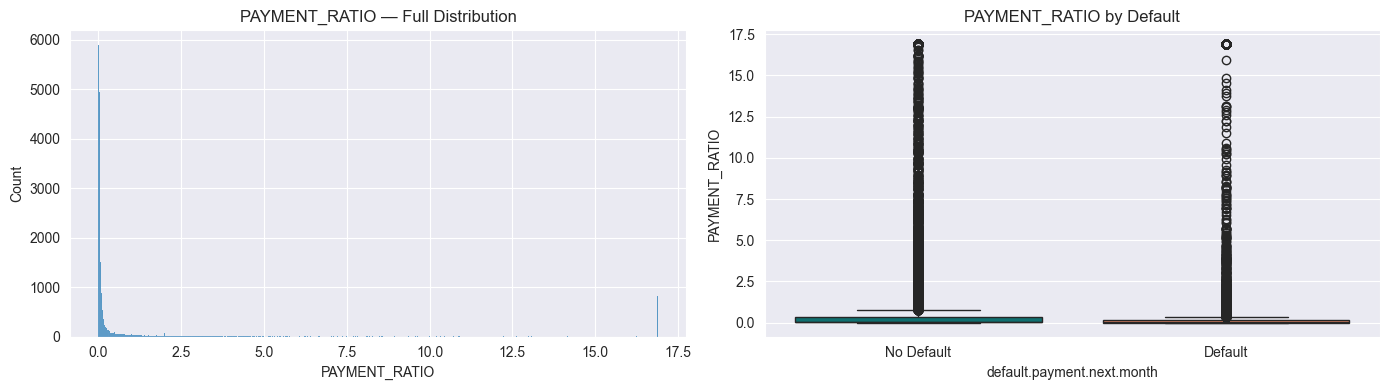

In [168]:
# Visualise the final PAYMENT_RATIO distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(data=df_featured, x='PAYMENT_RATIO', ax=axes[0])
axes[0].set_title('PAYMENT_RATIO — Full Distribution')

sns.boxplot(x='default.payment.next.month', y='PAYMENT_RATIO',
            data=df_featured, palette={'0': 'teal', '1': 'coral'}, ax=axes[1])
axes[1].set_title('PAYMENT_RATIO by Default')
axes[1].set_xticklabels(['No Default', 'Default'])

plt.tight_layout()
plt.show()

## Feature Engineering — PAYMENT_RATIO

### Definition
`PAYMENT_RATIO = PAY_AMT1 / BILL_AMT1`

Captures how much of the most recent bill (September 2005) was paid. More informative than raw payment amount alone since it measures repayment behaviour relative to the outstanding balance.

---

### Edge Cases Identified & Solutions

#### Case 1 — BILL_AMT1 = 0 and PAY_AMT1 = 0 → NaN
**Situation:** Customer had no outstanding bill and made no payment.
**Solution:** Set to 0 via `.fillna(0)` — neutral behaviour, no payment required.

#### Case 2 — BILL_AMT1 = 0 and PAY_AMT1 > 0 → inf
**Situation:** Customer made a payment despite having no outstanding bill.
**Solution:** Replaced with 99th percentile cap value — represents strong positive repayment behaviour.

#### Case 3 — BILL_AMT1 < 0 → Negative ratio
**Situation:** Customer has a credit balance — overpaid in a previous month.
**Initially considered** setting to 1, but this created an inconsistency — "overpaid previously" would be treated as equivalent to "paid exactly 100% this month" while "overpaid this month" gets a higher value.
**Further investigation** revealed extreme negative values down to -35,436 caused by very small negative BILL_AMT1 values in the denominator — mathematical artifacts with no meaningful signal.
**Solution:** Clipped to 0 via lower bound of clip.

#### Case 4 — PAYMENT_RATIO > 99th percentile → Extreme positive outliers
**Situation:** Max value of 11,453 found — extreme outlier caused by dividing by very small positive BILL_AMT1.
**Distribution analysis:**
- 75th percentile: 0.26
- 90th percentile: 1.07
- 95th percentile: 2.55
- 99th percentile: ~16.88
- Max: 11,453
**Solution:** Capped at 99th percentile — preserves 99% of real variation while removing noise.

---

### Final Solution
```python
# Calculate cap value from valid (non-inf, non-nan) values
valid_ratio = df_featured['PAYMENT_RATIO'][
    ~np.isinf(df_featured['PAYMENT_RATIO']) &
    ~df_featured['PAYMENT_RATIO'].isna()
]
cap_value = valid_ratio.quantile(0.99)

# Fix NaN, inf and clip to range [0, cap_value]
df_featured['PAYMENT_RATIO'] = df_featured['PAYMENT_RATIO'].fillna(0)
df_featured['PAYMENT_RATIO'] = df_featured['PAYMENT_RATIO'].replace([np.inf, -np.inf], cap_value)
df_featured['PAYMENT_RATIO'] = df_featured['PAYMENT_RATIO'].clip(0, cap_value)
```

### Final Range
`0 ≤ PAYMENT_RATIO ≤ 16.88 (99th percentile)`

- Lower bound of 0 handles NaN, negative values and their extreme artifacts
- Upper bound of 16.88 handles inf and extreme positive outliers
- All cases treated consistently using data-driven thresholds

## Feature Engineering — BILL_LIMIT_RATIO

In [169]:
print(f"Negative values in BILL_LIMIT_RATIO: {(df_featured['BILL_LIMIT_RATIO'] < 0).sum()}")
print(f"NaN in BILL_LIMIT_RATIO: {df_featured['BILL_LIMIT_RATIO'].isna().sum()}")
print(f"Inf in BILL_LIMIT_RATIO: {np.isinf(df_featured['BILL_LIMIT_RATIO']).sum()}")
print(f"\nDistribution:")
print(df_featured['BILL_LIMIT_RATIO'].describe())

Negative values in BILL_LIMIT_RATIO: 590
NaN in BILL_LIMIT_RATIO: 0
Inf in BILL_LIMIT_RATIO: 0

Distribution:
count    29965.000000
mean         0.424263
std          0.411451
min         -0.619892
25%          0.022300
50%          0.315278
75%          0.830325
max          6.455300
Name: BILL_LIMIT_RATIO, dtype: float64


In [170]:
print(f"Values above 1 (bill exceeds limit): {(df_featured['BILL_LIMIT_RATIO'] > 1).sum()}")
print(f"Values above 2: {(df_featured['BILL_LIMIT_RATIO'] > 2).sum()}")
print(f"\nPercentiles:")
df_featured['BILL_LIMIT_RATIO'].quantile([0.95, 0.99, 0.999])

Values above 1 (bill exceeds limit): 2115
Values above 2: 37

Percentiles:


0.950    1.013139
0.990    1.232441
0.999    2.140201
Name: BILL_LIMIT_RATIO, dtype: float64

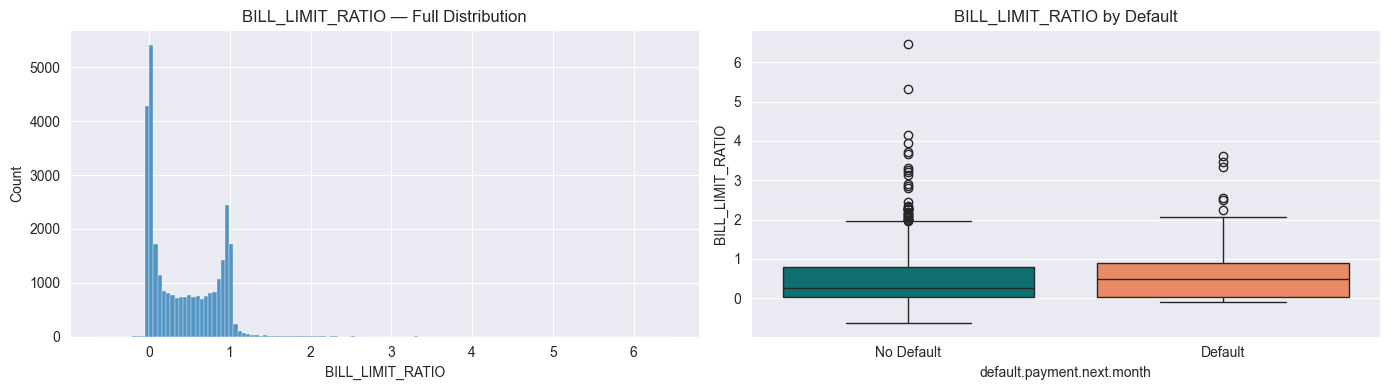

In [171]:
# Visualise the final BILL_LIMIT_RATIO distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(data=df_featured, x='BILL_LIMIT_RATIO', ax=axes[0])
axes[0].set_title('BILL_LIMIT_RATIO — Full Distribution')

sns.boxplot(x='default.payment.next.month', y='BILL_LIMIT_RATIO',
            data=df_featured, palette={'0': 'teal', '1': 'coral'}, ax=axes[1])
axes[1].set_title('BILL_LIMIT_RATIO by Default')
axes[1].set_xticklabels(['No Default', 'Default'])

plt.tight_layout()
plt.show()

## Feature Engineering — BILL_LIMIT_RATIO

### Definition
`BILL_LIMIT_RATIO = BILL_AMT1 / LIMIT_BAL`

Captures credit utilisation — how much of the credit limit is being used in the most recent month (September 2005). More informative than raw bill amount alone since a 50,000 NT bill on a 60,000 NT limit represents far greater financial pressure than the same bill on a 500,000 NT limit.

---

### Edge Cases Investigation

| Issue | Count | Decision |
|---|---|---|
| NaN | 0 | No action needed |
| Inf | 0 | No action needed |
| Negative values (BILL_AMT1 < 0) | 590 | Keep as-is |
| Values above 1 (bill exceeds limit) | 2,115 | Keep as-is |
| Values above 2 | 37 | Keep as-is |

**Percentiles:**
- 95th percentile: 1.01
- 99th percentile: 1.23
- 99.9th percentile: 2.14
- Max: 6.46

### Key Decisions
- **Negative values kept as-is** — bounded between -0.62 and 0, representing customers with a credit balance. Unlike PAYMENT_RATIO where negatives reached -35,436, these are fully interpretable values worth preserving as signal
- **No capping applied** — 99.9% of values sit below 2.14 and max is only 6.46. Values above 1 represent customers whose bills exceeded their credit limit due to interest and fees — a meaningful group (7% of data) that would lose important signal if capped

### Distribution
- Bimodal distribution with peaks near 0 and 1 — reflects two distinct customer behaviours: low utilisation and near-maxed out cards
- Defaulters show slightly higher median ratio and more spread — higher utilisation is associated with default as expected
- Right skewed with outliers — **Yeo-Johnson transformation will be applied inside the pipeline** for Logistic Regression

### Final Range
`-0.62 ≤ BILL_LIMIT_RATIO ≤ 6.46` — no cleaning required, all values are interpretable and meaningful

## Feature Engineering TOTAL_PAID_6MONTHS

In [172]:
print(f"NaN in TOTAL_PAID_6MONTHS: {df_featured['TOTAL_PAID_6MONTHS'].isna().sum()}")
print(f"Inf in TOTAL_PAID_6MONTHS: {np.isinf(df_featured['TOTAL_PAID_6MONTHS']).sum()}")
print(f"Negative values: {(df_featured['TOTAL_PAID_6MONTHS'] < 0).sum()}")
print(f"Zero values: {(df_featured['TOTAL_PAID_6MONTHS'] == 0).sum()}")
print(f"\nDistribution:")
print(df_featured['TOTAL_PAID_6MONTHS'].describe())

NaN in TOTAL_PAID_6MONTHS: 0
Inf in TOTAL_PAID_6MONTHS: 0
Negative values: 0
Zero values: 1401

Distribution:
count    2.996500e+04
mean     3.168778e+04
std      6.085384e+04
min      0.000000e+00
25%      6.700000e+03
50%      1.440000e+04
75%      3.360000e+04
max      3.764066e+06
Name: TOTAL_PAID_6MONTHS, dtype: float64


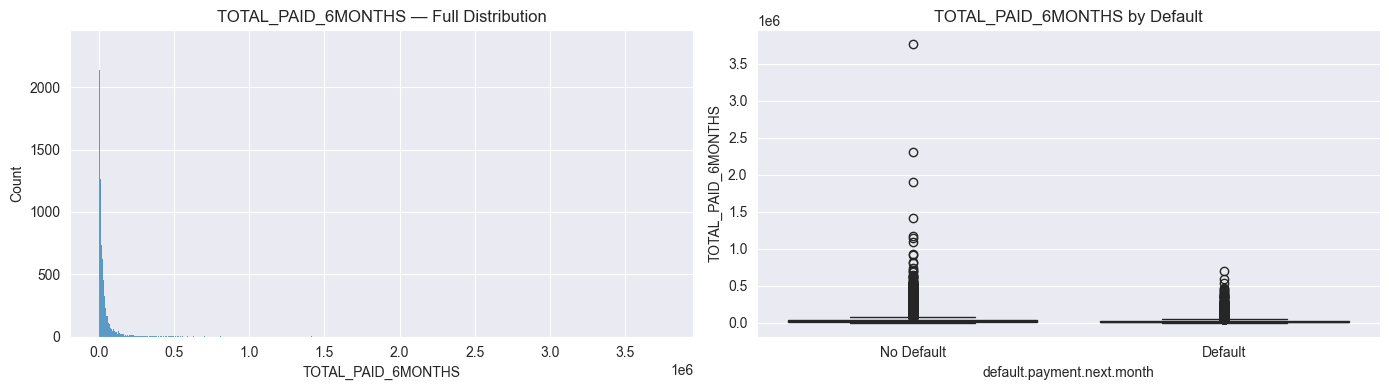

In [173]:
# Visualise the final TOTAL_PAID_6MONTHS distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(data=df_featured, x='TOTAL_PAID_6MONTHS', ax=axes[0])
axes[0].set_title('TOTAL_PAID_6MONTHS — Full Distribution')

sns.boxplot(x='default.payment.next.month', y='TOTAL_PAID_6MONTHS',
            data=df_featured, palette={'0': 'teal', '1': 'coral'}, ax=axes[1])
axes[1].set_title('TOTAL_PAID_6MONTHS by Default')
axes[1].set_xticklabels(['No Default', 'Default'])

plt.tight_layout()
plt.show()

## Feature Engineering — TOTAL_PAID_6MONTHS

### Definition
`TOTAL_PAID_6MONTHS = PAY_AMT1 + PAY_AMT2 + PAY_AMT3 + PAY_AMT4 + PAY_AMT5 + PAY_AMT6`

Aggregates payment behaviour across all 6 months (April–September 2005) into a single feature. Motivated by EDA finding that all 6 PAY_AMT columns showed the same consistent signal — non-defaulters make higher payments across every month. Rather than feeding 6 mildly correlated columns to the model, this single feature captures the overall payment behaviour more cleanly.

---

### Edge Cases Investigation

| Issue | Count | Decision |
|---|---|---|
| NaN | 0 | No action needed |
| Inf | 0 | No action needed |
| Negative values | 0 | No action needed |
| Zero values | 1,401 | Keep as-is — meaningful signal |

### Key Decisions
- **Zero values kept as-is** — 1,401 customers made zero payments across all 6 months. This is not a data quality issue, it is a strong signal of default risk and must be preserved
- **No capping applied** — max of 3,764,066 NT represents genuinely wealthy customers making large payments. These are real values, not artifacts

### Distribution
- Extremely right skewed with a massive spike near zero and a long tail up to 3.76 million NT
- Box plot shows clear separation between defaulters and non-defaulters — non-defaulters have a noticeably higher median, confirming EDA findings
- **Yeo-Johnson transformation will be applied inside the pipeline** for Logistic Regression — this is the most skewed of all three engineered features

### Final Range
`0 ≤ TOTAL_PAID_6MONTHS ≤ 3,764,066` — no cleaning required